# 28 - LSEG/Gemma sparse extreme rotation

**Question.** Can the best gross LSEG/Gemma cross-sectional result be turned
into a lower-turnover long-only strategy by trading only exact maximum-score
events?

Notebook 13 already identified Gemma `strongest_event` as the best gross arm,
so this is an **iterative, retrospective translation**, not a fresh holdout.
The return-blind activity audit found exact −1 and +1 events together on
80/167 sessions, including 28 in the first half and 52 in the second.

Three rules are frozen before the return cells below:

1. **Fixed-share basket:** initially equal-dollar shares in all 44 companies.
2. **Sparse brake:** when `strongest_event == -1.0`, cut that company's fixed
   shares to 25% for one open-to-open interval and leave the proceeds in cash.
3. **Sparse rotation:** make the same cut, but when at least one
   `strongest_event == +1.0` firm exists on that session, divide the released
   current-open notional equally across those positive-event firms. If no
   exact +1 exists, retain cash exactly as in the brake.

The 25% value is inherited from the existing risk chain. There is no score,
holding-period, breadth, or allocation sweep. All paths use the existing
15-minute information buffer, split-adjusted non-dividend-adjusted opens,
10 bps per traded side, explicit cash, and final liquidation.

The rotation-selection gate requires net Sharpe at least 0.10 above the brake,
paired return non-inferiority at −1 bp/day, incremental gross break-even above
10 bps/side, and nonnegative half-by-half Sharpe differences. Alpha and
useful-risk gates retain corrected return/downside and drawdown requirements.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.fixed_share import (  # noqa: E402
    build_sparse_extreme_targets,
    evaluate_fixed_share_targets,
    summarize_fixed_share_path,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402

SEED = 20260805
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
RISK_FRACTION = 0.25
BLOCK_LENGTH = 5
REPLICATIONS = 4_999
ARMS = ("basket", "negative_brake", "extreme_rotation")

GEMMA_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv",
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/28_lseg_gemma_sparse_extreme_rotation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Data, timing, and return-blind signal audit

Only the aggregate firm-open panel is loaded. No licensed headline text is
displayed or written. Every signal session must contain all 44 firms and have
a complete next-session 44-company price open.

In [2]:
gemma = pd.read_parquet(GEMMA_PATH)
gemma["session_date"] = pd.to_datetime(gemma["session_date"]).dt.normalize()
prices = pd.concat(
    [pd.read_csv(path, parse_dates=["session_date"]) for path in PRICE_PATHS],
    ignore_index=True,
)
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate Gemma firm-open rows")
if prices.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate price rows")

open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = sorted(gemma["symbol"].unique())
if len(symbols) != 44 or open_wide.shape[1] != 44:
    raise ValueError("expected the fixed 44-company population")
if not gemma.groupby("session_date")["symbol"].nunique().eq(44).all():
    raise ValueError("Gemma panel must contain all 44 firms on each session")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("Gemma sessions must be consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide.index):
    raise ValueError("last signal session has no next complete open")

strongest = gemma.pivot(index="session_date", columns="symbol", values="strongest_event").reindex(
    index=sessions,
    columns=open_wide.columns,
)
negative_flags = strongest.le(-1.0 + 1e-12)
positive_flags = strongest.ge(1.0 - 1e-12)
if (negative_flags & positive_flags).any().any():
    raise RuntimeError("positive and negative exact events overlap")
daily_activity = pd.DataFrame(
    {
        "session_date": sessions,
        "negative_firms": negative_flags.sum(axis=1).to_numpy(),
        "positive_firms": positive_flags.sum(axis=1).to_numpy(),
    }
)
daily_activity["both_sides"] = daily_activity["negative_firms"].gt(0) & daily_activity[
    "positive_firms"
].gt(0)
midpoint = len(sessions) // 2
half_sessions = {"first_half": sessions[:midpoint], "second_half": sessions[midpoint:]}

activity_rows = [
    {
        "period": "full",
        "sessions": len(sessions),
        "negative_firm_events": int(negative_flags.sum().sum()),
        "positive_firm_events": int(positive_flags.sum().sum()),
        "negative_active_sessions": int(negative_flags.any(axis=1).sum()),
        "positive_active_sessions": int(positive_flags.any(axis=1).sum()),
        "both_side_sessions": int(daily_activity["both_sides"].sum()),
    }
]
for half, index in half_sessions.items():
    use = daily_activity.loc[daily_activity["session_date"].isin(index)]
    activity_rows.append(
        {
            "period": half,
            "sessions": len(index),
            "negative_firm_events": int(use["negative_firms"].sum()),
            "positive_firm_events": int(use["positive_firms"].sum()),
            "negative_active_sessions": int(use["negative_firms"].gt(0).sum()),
            "positive_active_sessions": int(use["positive_firms"].gt(0).sum()),
            "both_side_sessions": int(use["both_sides"].sum()),
        }
    )
activity = pd.DataFrame(activity_rows)
coverage = pd.DataFrame(
    [
        {
            "firm_open_rows": len(gemma),
            "sessions": len(sessions),
            "companies": len(symbols),
            "first_entry_session": sessions.min(),
            "last_entry_session": sessions.max(),
            "last_return_end": open_wide.index[locations[-1] + 1],
            "repaired_price_rows": int(prices["repaired"].sum()),
        }
    ]
)
display(coverage)
display(activity)

,firm_open_rows,sessions,companies,first_entry_session,last_entry_session,last_return_end,repaired_price_rows
0,7348,167,44,2025-10-27,2026-06-26,2026-06-29,0


,period,sessions,negative_firm_events,positive_firm_events,negative_active_sessions,positive_active_sessions,both_side_sessions
0,full,167,143,244,99,132,80
1,first_half,83,53,99,41,56,28
2,second_half,84,90,145,58,76,52


## Build target shares and audit capital transfer

The rotation transfers exactly the notional removed from −1 firms to +1 firms
at the same entry open. On negative-only days it is identical to the cash
brake. The basket is cost-funded at inception and never shorts a company.

In [3]:
empty_flags = pd.DataFrame(False, index=sessions, columns=open_wide.columns)
targets = {
    "basket": build_sparse_extreme_targets(
        open_wide,
        sessions,
        empty_flags,
        empty_flags,
        risk_fraction=RISK_FRACTION,
        entry_cost_bps=COST_BPS,
        reallocate_to_positive=False,
    ),
    "negative_brake": build_sparse_extreme_targets(
        open_wide,
        sessions,
        negative_flags,
        positive_flags,
        risk_fraction=RISK_FRACTION,
        entry_cost_bps=COST_BPS,
        reallocate_to_positive=False,
    ),
    "extreme_rotation": build_sparse_extreme_targets(
        open_wide,
        sessions,
        negative_flags,
        positive_flags,
        risk_fraction=RISK_FRACTION,
        entry_cost_bps=COST_BPS,
        reallocate_to_positive=True,
    ),
}

target_audit_rows = []
for session in sessions:
    price = open_wide.loc[session]
    base_notional = float((targets["basket"].loc[session] * price).sum())
    brake_notional = float((targets["negative_brake"].loc[session] * price).sum())
    rotation_notional = float((targets["extreme_rotation"].loc[session] * price).sum())
    target_audit_rows.append(
        {
            "session_date": session,
            "negative_firms": int(negative_flags.loc[session].sum()),
            "positive_firms": int(positive_flags.loc[session].sum()),
            "base_notional": base_notional,
            "brake_notional": brake_notional,
            "rotation_notional": rotation_notional,
            "released_to_cash_brake": base_notional - brake_notional,
            "reallocated_notional": rotation_notional - brake_notional,
        }
    )
target_audit = pd.DataFrame(target_audit_rows)
both = target_audit["negative_firms"].gt(0) & target_audit["positive_firms"].gt(0)
negative_only = target_audit["negative_firms"].gt(0) & target_audit["positive_firms"].eq(0)
assert np.allclose(
    target_audit.loc[both, "rotation_notional"],
    target_audit.loc[both, "base_notional"],
    atol=1e-12,
)
assert np.allclose(
    target_audit.loc[negative_only, "rotation_notional"],
    target_audit.loc[negative_only, "brake_notional"],
    atol=1e-12,
)
capital_audit = pd.DataFrame(
    [
        {
            "both_side_sessions": int(both.sum()),
            "negative_only_sessions": int(negative_only.sum()),
            "max_both_side_notional_error": float(
                np.max(
                    np.abs(
                        target_audit.loc[both, "rotation_notional"]
                        - target_audit.loc[both, "base_notional"]
                    )
                )
            ),
            "max_negative_only_path_error": float(
                np.max(
                    np.abs(
                        target_audit.loc[negative_only, "rotation_notional"]
                        - target_audit.loc[negative_only, "brake_notional"]
                    )
                )
            ),
            "max_rotation_single_name_notional_share": float(
                max(
                    (
                        (targets["extreme_rotation"].loc[session] * open_wide.loc[session])
                        / (targets["extreme_rotation"].loc[session] * open_wide.loc[session]).sum()
                    ).max()
                    for session in sessions
                )
            ),
        }
    ]
)
display(capital_audit)

,both_side_sessions,negative_only_sessions,max_both_side_notional_error,max_negative_only_path_error,max_rotation_single_name_notional_share
0,80,19,0.000000,0.000000,0.089535


## Full-period backtests

In [4]:
daily_paths = {
    arm: evaluate_fixed_share_targets(
        open_wide,
        target,
        cost_bps_per_side=COST_BPS,
    )
    for arm, target in targets.items()
}
results = pd.DataFrame(
    [{"arm": arm, **summarize_fixed_share_path(daily)} for arm, daily in daily_paths.items()]
)
display(
    results[
        [
            "arm",
            "n_sessions",
            "sharpe_gross",
            "sharpe_net",
            "total_return_gross",
            "total_return_net",
            "ann_vol_net",
            "max_drawdown",
            "mean_turnover",
            "mean_gross_exposure",
            "breakeven_bps_per_side",
        ]
    ]
)

,arm,n_sessions,sharpe_gross,sharpe_net,total_return_gross,total_return_net,ann_vol_net,max_drawdown,mean_turnover,mean_gross_exposure,breakeven_bps_per_side
0,basket,167,1.499652,1.471957,0.102202,0.100101,0.101297,-0.059252,0.012007,1.000000,502.310199
1,negative_brake,167,1.614350,1.526075,0.109281,0.102904,0.100147,-0.058219,0.036057,0.984688,177.770574
2,extreme_rotation,167,1.692340,1.560079,0.117279,0.107572,0.102183,-0.057376,0.054729,0.996700,125.122992


## Paired inference and multiplicity

The declared family contains rotation versus basket and rotation versus brake
for daily net return and squared downside. Positive differences favour the
rotation. BH is applied separately over the two tests for each outcome.

In [5]:
inference_rows = []
for comparator_offset, comparator in enumerate(("basket", "negative_brake")):
    for outcome_offset, outcome in enumerate(("net_return", "downside_sq")):
        if outcome == "net_return":
            challenger = daily_paths["extreme_rotation"]
            baseline = daily_paths[comparator]
        else:
            challenger = daily_paths[comparator]
            baseline = daily_paths["extreme_rotation"]
        estimate = paired_block_bootstrap_difference(
            challenger,
            baseline,
            value_col=outcome,
            block_length=BLOCK_LENGTH,
            replications=REPLICATIONS,
            seed=SEED + comparator_offset * 4 + outcome_offset,
        )
        inference_rows.append(
            {
                "comparator": comparator,
                "outcome": outcome,
                "positive_favours_rotation": True,
                **estimate,
            }
        )
inference = pd.DataFrame(inference_rows)
inference["bh_reject_q05"] = False
for _outcome, index in inference.groupby("outcome").groups.items():
    inference.loc[index, "bh_reject_q05"] = benjamini_hochberg(
        inference.loc[index, "p_two_sided"].tolist(),
        q=0.05,
    )
display(inference)

,comparator,outcome,positive_favours_rotation,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,basket,net_return,True,167,0.000041,-0.000027,0.000110,0.240400,5,4999,20260805,False
1,basket,downside_sq,True,167,-0.000000,-0.000001,0.000000,0.484200,5,4999,20260806,False
2,negative_brake,net_return,True,167,0.000026,-0.000024,0.000081,0.323400,5,4999,20260809,False
3,negative_brake,downside_sq,True,167,-0.000001,-0.000001,-0.000000,0.007400,5,4999,20260810,True


## Cost and temporal stability

Each half is independently initialised and liquidated so turnover and returns
remain internally consistent.

In [6]:
cost_rows = []
for cost in COST_GRID:
    cost_targets = {
        "basket": build_sparse_extreme_targets(
            open_wide,
            sessions,
            empty_flags,
            empty_flags,
            risk_fraction=RISK_FRACTION,
            entry_cost_bps=cost,
            reallocate_to_positive=False,
        ),
        "negative_brake": build_sparse_extreme_targets(
            open_wide,
            sessions,
            negative_flags,
            positive_flags,
            risk_fraction=RISK_FRACTION,
            entry_cost_bps=cost,
            reallocate_to_positive=False,
        ),
        "extreme_rotation": build_sparse_extreme_targets(
            open_wide,
            sessions,
            negative_flags,
            positive_flags,
            risk_fraction=RISK_FRACTION,
            entry_cost_bps=cost,
            reallocate_to_positive=True,
        ),
    }
    for arm, target in cost_targets.items():
        daily = evaluate_fixed_share_targets(open_wide, target, cost_bps_per_side=cost)
        cost_rows.append(
            {"arm": arm, "cost_bps_per_side": cost, **summarize_fixed_share_path(daily)}
        )
cost_curve = pd.DataFrame(cost_rows)

temporal_rows = []
for half, index in half_sessions.items():
    half_negative = negative_flags.loc[index]
    half_positive = positive_flags.loc[index]
    half_empty = empty_flags.loc[index]
    half_targets = {
        "basket": build_sparse_extreme_targets(
            open_wide,
            index,
            half_empty,
            half_empty,
            risk_fraction=RISK_FRACTION,
            entry_cost_bps=COST_BPS,
            reallocate_to_positive=False,
        ),
        "negative_brake": build_sparse_extreme_targets(
            open_wide,
            index,
            half_negative,
            half_positive,
            risk_fraction=RISK_FRACTION,
            entry_cost_bps=COST_BPS,
            reallocate_to_positive=False,
        ),
        "extreme_rotation": build_sparse_extreme_targets(
            open_wide,
            index,
            half_negative,
            half_positive,
            risk_fraction=RISK_FRACTION,
            entry_cost_bps=COST_BPS,
            reallocate_to_positive=True,
        ),
    }
    for arm, target in half_targets.items():
        daily = evaluate_fixed_share_targets(open_wide, target, cost_bps_per_side=COST_BPS)
        temporal_rows.append({"period": half, "arm": arm, **summarize_fixed_share_path(daily)})
temporal = pd.DataFrame(temporal_rows)
display(cost_curve[["arm", "cost_bps_per_side", "sharpe_net", "total_return_net"]])
display(temporal[["period", "arm", "sharpe_gross", "sharpe_net", "total_return_net", "max_drawdown"]])

,arm,cost_bps_per_side,sharpe_net,total_return_net
0,basket,0.000000,1.499699,0.102304
1,negative_brake,0.000000,1.614393,0.109390
2,extreme_rotation,0.000000,1.692381,0.117396
3,basket,1.000000,1.496947,0.102083
4,negative_brake,1.000000,1.605597,0.108741
5,extreme_rotation,1.000000,1.679198,0.116413
6,basket,2.000000,1.494190,0.101863
7,negative_brake,2.000000,1.596792,0.108092
8,extreme_rotation,2.000000,1.666005,0.115430
9,basket,5.000000,1.485889,0.101202


,period,arm,sharpe_gross,sharpe_net,total_return_net,max_drawdown
0,first_half,basket,2.708375,2.647852,0.088891,-0.032443
1,first_half,negative_brake,2.765413,2.655738,0.088273,-0.033153
2,first_half,extreme_rotation,2.715962,2.572534,0.086697,-0.033831
3,second_half,basket,0.405538,0.345547,0.009883,-0.055669
4,second_half,negative_brake,0.579327,0.446773,0.013112,-0.054758
5,second_half,extreme_rotation,0.761843,0.577617,0.017875,-0.054160


## Frozen decision gates

In [7]:
result_index = results.set_index("arm")
inference_index = inference.set_index(["comparator", "outcome"])
rotation = result_index.loc["extreme_rotation"]
brake = result_index.loc["negative_brake"]
basket = result_index.loc["basket"]
rotation_brake_return = inference_index.loc[("negative_brake", "net_return")]
rotation_base_return = inference_index.loc[("basket", "net_return")]
rotation_base_downside = inference_index.loc[("basket", "downside_sq")]

temporal_index = temporal.set_index(["period", "arm"])
half_sharpe_differences = {
    half: float(
        temporal_index.loc[(half, "extreme_rotation"), "sharpe_net"]
        - temporal_index.loc[(half, "negative_brake"), "sharpe_net"]
    )
    for half in half_sessions
}
incremental_turnover = float(rotation["mean_turnover"] - brake["mean_turnover"])
incremental_gross_mean = float(rotation["mean_gross"] - brake["mean_gross"])
incremental_breakeven = (
    10_000.0 * incremental_gross_mean / incremental_turnover
    if incremental_turnover > 0
    else np.nan
)
drawdown_relative_vs_base = float(
    1.0 - abs(rotation["max_drawdown"]) / abs(basket["max_drawdown"])
)
rotation_selection_gate = bool(
    rotation["sharpe_net"] >= brake["sharpe_net"] + 0.10
    and rotation_brake_return["ci_low"] * 10_000 >= -1.0
    and incremental_breakeven > COST_BPS
    and all(value >= 0 for value in half_sharpe_differences.values())
)
alpha_gate = bool(
    rotation_base_return["mean_difference"] > 0
    and rotation_base_return["ci_low"] > 0
    and rotation_base_return["bh_reject_q05"]
    and rotation["mean_net"] > 0
)
useful_risk_gate = bool(
    rotation["sharpe_net"] >= basket["sharpe_net"] + 0.10
    and drawdown_relative_vs_base >= 0.20
    and rotation_base_return["ci_low"] * 10_000 >= -1.0
    and rotation_base_downside["mean_difference"] > 0
    and rotation_base_downside["bh_reject_q05"]
)
gates = pd.DataFrame(
    [
        {
            "rotation_selection_gate": rotation_selection_gate,
            "alpha_gate": alpha_gate,
            "useful_risk_gate": useful_risk_gate,
            "rotation_minus_brake_sharpe": float(rotation["sharpe_net"] - brake["sharpe_net"]),
            "rotation_minus_brake_bps_day": float(rotation_brake_return["mean_difference"] * 10_000),
            "rotation_minus_brake_ci_low_bps_day": float(rotation_brake_return["ci_low"] * 10_000),
            "incremental_gross_breakeven_bps_per_side": incremental_breakeven,
            "first_half_rotation_minus_brake_sharpe": half_sharpe_differences["first_half"],
            "second_half_rotation_minus_brake_sharpe": half_sharpe_differences["second_half"],
            "rotation_minus_base_sharpe": float(rotation["sharpe_net"] - basket["sharpe_net"]),
            "rotation_minus_base_bps_day": float(rotation_base_return["mean_difference"] * 10_000),
            "rotation_minus_base_ci_low_bps_day": float(rotation_base_return["ci_low"] * 10_000),
            "drawdown_relative_improvement_vs_base": drawdown_relative_vs_base,
            "downside_bh_reject_vs_base": bool(rotation_base_downside["bh_reject_q05"]),
        }
    ]
)
display(gates)

,rotation_selection_gate,alpha_gate,useful_risk_gate,rotation_minus_brake_sharpe,rotation_minus_brake_bps_day,rotation_minus_brake_ci_low_bps_day,incremental_gross_breakeven_bps_per_side,first_half_rotation_minus_brake_sharpe,second_half_rotation_minus_brake_sharpe,rotation_minus_base_sharpe,rotation_minus_base_bps_day,rotation_minus_base_ci_low_bps_day,drawdown_relative_improvement_vs_base,downside_bh_reject_vs_base
0,False,False,False,0.034004,0.261182,-0.237670,23.460950,-0.083204,0.130844,0.088122,0.409048,-0.272952,0.031662,False


## Figures

findfont: Failed to find font weight medium, now using 400.


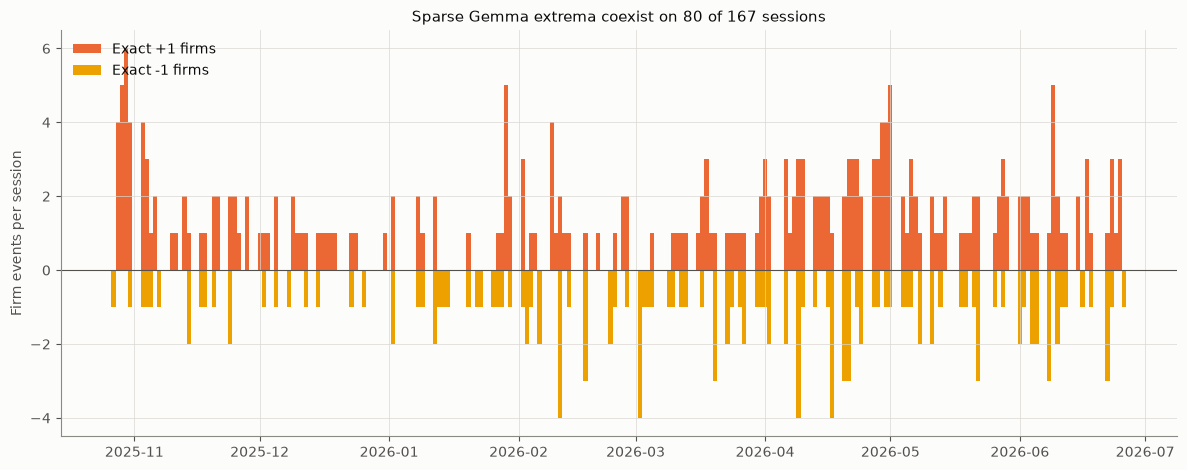

In [8]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.bar(
    daily_activity["session_date"],
    daily_activity["positive_firms"],
    width=1.0,
    color=CATEGORICAL[1],
    label="Exact +1 firms",
)
ax.bar(
    daily_activity["session_date"],
    -daily_activity["negative_firms"],
    width=1.0,
    color=CATEGORICAL[3],
    label="Exact -1 firms",
)
ax.axhline(0.0, color=INK["reference"], linewidth=0.8)
ax.set_ylabel("Firm events per session")
ax.set_title("Sparse Gemma extrema coexist on 80 of 167 sessions")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "extreme_event_activity.png", dpi=170, bbox_inches="tight")
plt.show()

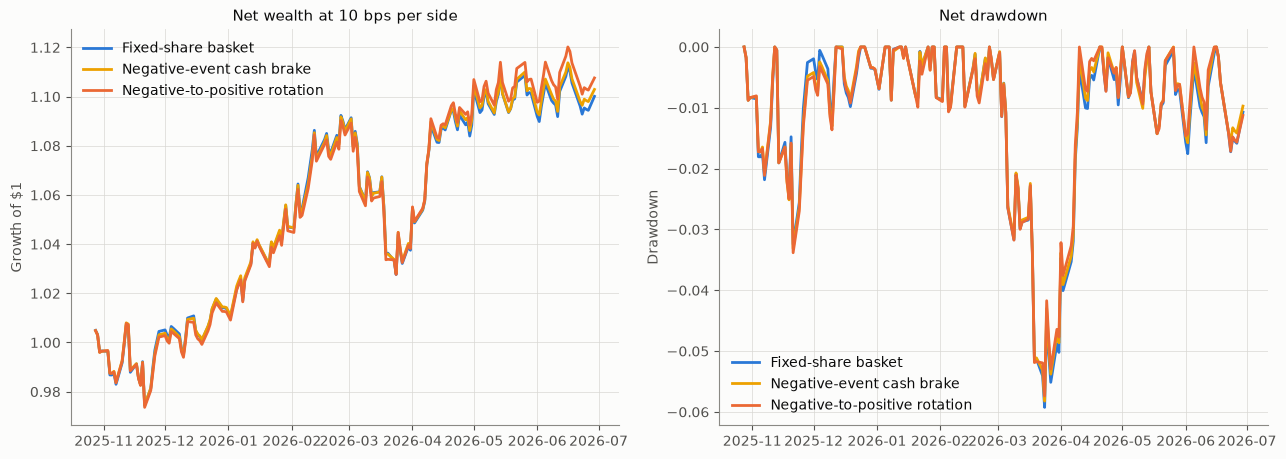

In [9]:
labels = {
    "basket": "Fixed-share basket",
    "negative_brake": "Negative-event cash brake",
    "extreme_rotation": "Negative-to-positive rotation",
}
colours = dict(zip(ARMS, (CATEGORICAL[0], CATEGORICAL[3], CATEGORICAL[1]), strict=True))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
for arm in ARMS:
    daily = daily_paths[arm]
    equity = (1.0 + daily["net_return"]).cumprod()
    drawdown = equity / np.maximum.accumulate(np.r_[1.0, equity])[-len(equity):] - 1.0
    axes[0].plot(daily["return_end_date"], equity, label=labels[arm], color=colours[arm])
    axes[1].plot(daily["return_end_date"], drawdown, label=labels[arm], color=colours[arm])
axes[0].set_title("Net wealth at 10 bps per side")
axes[0].set_ylabel("Growth of $1")
axes[1].set_title("Net drawdown")
axes[1].set_ylabel("Drawdown")
axes[0].legend(loc="best")
axes[1].legend(loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

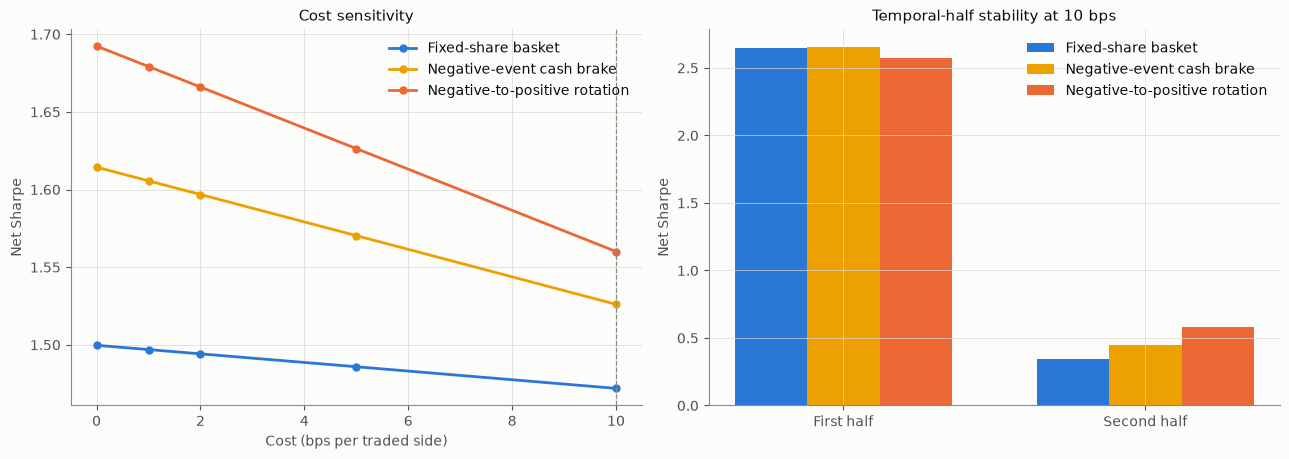

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
for arm in ARMS:
    line = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[0].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        label=labels[arm],
        color=colours[arm],
    )
half_plot = temporal.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["first_half", "second_half"]
)
x = np.arange(len(half_plot))
width = 0.24
for offset, arm in enumerate(ARMS):
    axes[1].bar(
        x + (offset - 1) * width,
        half_plot[arm],
        width,
        label=labels[arm],
        color=colours[arm],
    )
axes[0].axvline(COST_BPS, color=INK["muted"], linestyle="--", linewidth=0.9)
axes[0].set_xlabel("Cost (bps per traded side)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Cost sensitivity")
axes[0].legend(loc="best")
axes[1].set_xticks(x, ["First half", "Second half"])
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Temporal-half stability at 10 bps")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_and_temporal_stability.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [11]:
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
activity.to_csv(OUTPUT_DIR / "activity.csv", index=False)
capital_audit.to_csv(OUTPUT_DIR / "capital_transfer_audit.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "notebook": "28_lseg_gemma_sparse_extreme_rotation",
    "analysis_status": "iterative_retrospective_non_pooled_lseg_translation_2026-08-05",
    "selection_disclosure": (
        "Notebook 13 already opened this return window and selected Gemma strongest_event as the best gross arm; "
        "the exact +/-1 rotation is an iterative semantic translation."
    ),
    "git_commit_at_execution": git_commit,
    "population": {
        "companies": len(symbols),
        "firm_open_rows": len(gemma),
        "sessions": len(sessions),
        "first_entry_session": str(sessions.min().date()),
        "last_entry_session": str(sessions.max().date()),
    },
    "design": {
        "base": "initially equal-dollar fixed-share 44-company basket",
        "negative_event": "Gemma strongest_event == -1.0",
        "positive_event": "Gemma strongest_event == +1.0",
        "risk_fraction": RISK_FRACTION,
        "rotation": "reallocate current-open notional released from exact -1 firms equally across exact +1 firms; otherwise cash",
        "cost_bps_per_traded_side": COST_BPS,
        "cost_grid": list(COST_GRID),
        "cash_return": 0.0,
        "final_liquidation": True,
        "bootstrap": {
            "block_length_sessions": BLOCK_LENGTH,
            "replications": REPLICATIONS,
            "seed": SEED,
        },
        "multiplicity": "BH separately over two rotation-comparator return tests and two downside tests",
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "activity": json.loads(activity.to_json(orient="records")),
    "capital_transfer_audit": json.loads(capital_audit.to_json(orient="records"))[0],
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(inference.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "retrospective eight-month window already opened by Notebook 13",
        "strongest_event was selected after its earlier gross result",
        "exact +/-1 events depend on Gemma's discrete score resolution and tie abstention",
        "44 large US companies are not a diversified market index",
        "price returns are split-adjusted but not dividend-adjusted",
        "cash earns zero",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

rotation_verdict = "passes" if rotation_selection_gate else "does not pass"
alpha_verdict = "passes" if alpha_gate else "does not pass"
risk_verdict = "passes" if useful_risk_gate else "does not pass"
display(
    Markdown(
        f"""### Decision

The sparse negative-to-positive rotation **{rotation_verdict}** the translation
gate, **{alpha_verdict}** the alpha gate, and **{risk_verdict}** the useful-risk
gate.

- Basket gross/net Sharpe: **{basket['sharpe_gross']:.3f}/{basket['sharpe_net']:.3f}**;
  net return **{basket['total_return_net']:.2%}**.
- Cash-brake gross/net Sharpe: **{brake['sharpe_gross']:.3f}/{brake['sharpe_net']:.3f}**;
  net return **{brake['total_return_net']:.2%}**.
- Rotation gross/net Sharpe: **{rotation['sharpe_gross']:.3f}/{rotation['sharpe_net']:.3f}**;
  net return **{rotation['total_return_net']:.2%}**.
- Rotation minus brake: **{rotation_brake_return['mean_difference'] * 10_000:.3f} bps/day**,
  95% block interval **[{rotation_brake_return['ci_low'] * 10_000:.3f},
  {rotation_brake_return['ci_high'] * 10_000:.3f}]**.
- Incremental gross break-even versus the brake: **{incremental_breakeven:.2f} bps/side**.

This is a sparse translation of an already-selected signal. A passing gate
would identify a candidate for new data; it would not turn this window into
holdout alpha.
"""
    )
)

### Decision

The sparse negative-to-positive rotation **does not pass** the translation
gate, **does not pass** the alpha gate, and **does not pass** the useful-risk
gate.

- Basket gross/net Sharpe: **1.500/1.472**;
  net return **10.01%**.
- Cash-brake gross/net Sharpe: **1.614/1.526**;
  net return **10.29%**.
- Rotation gross/net Sharpe: **1.692/1.560**;
  net return **10.76%**.
- Rotation minus brake: **0.261 bps/day**,
  95% block interval **[-0.238,
  0.807]**.
- Incremental gross break-even versus the brake: **23.46 bps/side**.

This is a sparse translation of an already-selected signal. A passing gate
would identify a candidate for new data; it would not turn this window into
holdout alpha.
